# OptiAbt

In [1]:
from pathlib import Path
import sys
import os
import pickle
import copy

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator import MultiExperimentAnalyzer, FrostEvaporatorSimulation, SimulationVisualizer


##############################################################################################
# Opti Abt
##############################################################################################

path_exp_abt = Path(r"D:\mbc_nba\OptiAbt_Daten\Versuche\CSV_Export")
experiment_groups_abt = {
    "+3 °C":  [52, 53, 55, 56],
    "+0 °C":  [40, 41, 42, 43, 44],
    "-7 °C":  [27, 28, 29, 30],
    "-12 °C": [13, 18],
}
# experiment_groups_abt = {
#     "Abt-a": [56],
#     "Abt-b": [40],
#     "Abt-c": [28],
#     # "Abt-d": [13],
# }


analyzer_abt = MultiExperimentAnalyzer(experiment_type='OptiAbt')
sim_abt = FrostEvaporatorSimulation("config_OptiAbt.yaml")
viz_abt = SimulationVisualizer(sim_abt.params)
cutoff_pct = 0.05
viz_abt = SimulationVisualizer(sim_abt.params)
cutoff_pct = 0.05

# new_factors = {
#     'h_conv_air':          0.9,
#     'betta_intercept_air': 1.0,
#     'betta_slope_air':     0.0,
#     'surface_density':     1.0,
#     'k_frost':             1.0,
#     'frost_diffusion':     1.0,
#     'pressure_loss':       1.0,
# }


new_factors = {
    'h_conv_air':          0.950,
    'betta_intercept_air': 1.000,
    'betta_slope_air':     0.000,
    'surface_density':     1.256,
    'k_frost':             1.031,
    'frost_diffusion':     1.303,
    'pressure_loss':       0.734,
}


new_model_choices = {
    'frost_density_choice':      'hayashi_1977',
    'frost_conductivity_choice': 'yonko_sepsy_1967',
    'h_conv_air_choice':         'Wang',
}

sim_abt.update_correction_factors(new_factors, new_model_choices)

all_sim_results = {}


for group_name, experiment_ids in experiment_groups_abt.items():
    
    print(f"\n{'='*40}")
    print(f"Processing Group: {group_name}")
    print(f"IDs: {experiment_ids}")
    print(f"{'='*40}")

    # Flag for the group that uses the melted mass measurement
    use_melted = False
    if group_name == "+3 °C" or group_name == "Abt-a":
        use_melted = True

    try:
        # Run analysis
        exp_data = analyzer_abt.analyze(
            exp_ids=experiment_ids, 
            data_path=path_exp_abt, 
            cutoff_pct=cutoff_pct, 
            time_step=sim_abt.params.time_step
        )

        # Run Simulation
        states_history, inputs_history = sim_abt.run_validation(exp_data)

        # Save the histories to our dictionary
        all_sim_results[group_name] = {
            'experiment_name': "OptiAbt",
            'path_exp'       : path_exp_abt,
            'params'         : copy.deepcopy(sim_abt.params),
            'experiment_ids' : experiment_ids,
            'cutoff_pct'     : cutoff_pct,
            'inputs_history' : inputs_history,
            'states_history' : states_history,
        }

        # Plot (Pass the new use_melted_mass argument)
        # viz_abt.plot_comparison(states_history, inputs_history, experiment_ids, path_exp_abt, cutoff_pct, save_fig=False, group_name=group_name, experiment_name="OptiAbt", use_melted_mass=use_melted)
        # print(viz_abt.get_relative_error_table(states_history, inputs_history, experiment_ids, path_exp_abt, cutoff_pct, experiment_name="OptiAbt", use_melted_mass=use_melted))
        # viz_abt.plot_detailed(states_history, inputs_history, experiment_ids)
        # viz_abt.plot_roughness(states_history, experiment_ids[0])
        # viz_abt.plot_frost_distribution(states_history)
        # viz_abt.plot_debug(states_history, inputs_history, experiment_ids[0])

    except Exception as e:
        import traceback
        print(f"!!! CRITICAL FAILURE in Group {group_name} !!!")
        print(f"Error Message: {e}")
        traceback.print_exc()

# Save the entire dictionary to a pickle file
save_path = "optiabt_histories.pkl"
with open(save_path, "wb") as f:
    pickle.dump(all_sim_results, f)

print(f"\nSuccessfully saved all simulation histories to: {save_path}")

Model initialized with fluid: R134a
Model initialized with fluid: R134a

Processing Group: +3 °C
IDs: [52, 53, 55, 56]
--- Aggregating Data (OptiAbt) for Experiments: [52, 53, 55, 56] ---


d:\mbc_nba\vclibpy\frost_evaporator_nba\frost_evaporator\physics\fan_system_model.py:260: UserWarning: [Wang Correlation Validity] Transverse Pitch (Pt) value 50.00 is outside the valid range [17.7 - 31.75]. Results may be inaccurate.
  warnings.warn(
d:\mbc_nba\vclibpy\frost_evaporator_nba\frost_evaporator\physics\fan_system_model.py:260: UserWarning: [Wang Correlation Validity] Transverse Pitch (Pt) value 50.00 is outside the valid range [17.7 - 31.75]. Results may be inaccurate.
  warnings.warn(


--- Simulation of Experiment Combined_4_OptiAbt ---
--- Priming Evaporator Model ---
--- Starting Simulation ---


Sim Combined_4_OptiAbt: 100%|██████████| 20/20 [00:22<00:00,  1.13s/it, Frost Surface Temp > 0°C in Layers 1, 2, 3, 4, 5]



Processing Group: +0 °C
IDs: [40, 41, 42, 43, 44]
--- Aggregating Data (OptiAbt) for Experiments: [40, 41, 42, 43, 44] ---
--- Simulation of Experiment Combined_5_OptiAbt ---
--- Priming Evaporator Model ---
--- Starting Simulation ---


...


Processing Group: -7 °C
IDs: [27, 28, 29, 30]
--- Aggregating Data (OptiAbt) for Experiments: [27, 28, 29, 30] ---
--- Simulation of Experiment Combined_4_OptiAbt ---
--- Priming Evaporator Model ---
--- Starting Simulation ---


Sim Combined_4_OptiAbt: 100%|██████████| 20/20 [00:10<00:00,  1.95it/s]



Processing Group: -12 °C
IDs: [13, 18]
--- Aggregating Data (OptiAbt) for Experiments: [13, 18] ---
--- Simulation of Experiment Combined_2_OptiAbt ---
--- Priming Evaporator Model ---
--- Starting Simulation ---


Sim Combined_2_OptiAbt: 100%|██████████| 20/20 [00:07<00:00,  2.68it/s]



Successfully saved all simulation histories to: optiabt_histories.pkl


# OptiHorst

In [2]:
from pathlib import Path
import sys
import os
import pickle
import copy

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator import MultiExperimentAnalyzer, FrostEvaporatorSimulation, SimulationVisualizer


##############################################################################################
# Opti Abt
##############################################################################################


path_exp_horst = Path(r"D:\mbc_nba\OptiHorst\Daten\Abtauen\CSV_Export")
experiment_groups_horst = {
    "+6°C":  [96,97,119,120,121],
    "-1°C":  [25,26,27,64,28],
    "-3°C":  [44,45,46,75],
    "-5°C":  [78,102,103,104],
    "-10°C": [60,61,62,83,84],
}


analyzer_horst = MultiExperimentAnalyzer(experiment_type='OptiHorst')
sim_horst      = FrostEvaporatorSimulation("config_OptiHorst.yaml")
viz_horst      = SimulationVisualizer(sim_horst.params)
cutoff_pct = 0.05


new_factors = {
    'h_conv_air':          0.950,
    'betta_intercept_air': 0.401,
    'betta_slope_air':     0.000,
    'surface_density':     1.256,
    'k_frost':             1.031,
    'frost_diffusion':     1.303,
    'pressure_loss':       0.734,
}



new_model_choices = {
    'frost_density_choice':      'hayashi_1977',
    'frost_conductivity_choice': 'yonko_sepsy_1967',
    'h_conv_air_choice':         'Wang',
}

sim_horst.update_correction_factors(new_factors, new_model_choices)

all_sim_results = {}


for group_name, experiment_ids in experiment_groups_horst.items():
    
    print(f"\n{'='*40}")
    print(f"Processing Group: {group_name}")
    print(f"IDs: {experiment_ids}")
    print(f"{'='*40}")

    try:
        # Run analysis
        exp_data = analyzer_horst.analyze(
            exp_ids=experiment_ids, 
            data_path=path_exp_horst, 
            cutoff_pct=cutoff_pct, 
            time_step=sim_horst.params.time_step
        )

        # Run Simulation
        states_history, inputs_history = sim_horst.run_validation(exp_data)

        # Save the histories to our dictionary
        all_sim_results[group_name] = {
            'experiment_name': "OptiHorst",
            'path_exp'       : path_exp_horst,
            'params'         : copy.deepcopy(sim_horst.params),
            'experiment_ids' : experiment_ids,
            'cutoff_pct'     : cutoff_pct,
            'inputs_history' : inputs_history,
            'states_history' : states_history,
        }

        # Plot 
        # viz_horst.plot_comparison(states_history, inputs_history, experiment_ids, path_exp_horst, cutoff_pct, save_fig=False, group_name=group_name, experiment_name="OptiHorst")
        # viz_horst.plot_detailed(states_history, inputs_history, experiment_ids)
        # viz_horst.plot_roughness(states_history, experiment_ids[0])
        # viz_horst.plot_frost_distribution(states_history)
        # viz_horst.plot_debug(states_history, inputs_history, experiment_ids[0])
        

    except Exception as e:
        import traceback
        print(f"!!! CRITICAL FAILURE in Group {group_name} !!!")
        print(f"Error Message: {e}")
        traceback.print_exc()


# --- NEW: Save the entire dictionary to a pickle file ---
save_path = "optihorst_histories.pkl"
with open(save_path, "wb") as f:
    pickle.dump(all_sim_results, f)

print(f"\nSuccessfully saved all simulation histories to: {save_path}")


Model initialized with fluid: R32.FLD|R125.FLD
Model initialized with fluid: R32.FLD|R125.FLD

Processing Group: +6°C
IDs: [96, 97, 119, 120, 121]
--- Aggregating Data (OptiHorst) for Experiments: [96, 97, 119, 120, 121] ---
--- Simulation of Experiment Combined_5_OptiHorst ---
--- Priming Evaporator Model ---
--- Starting Simulation ---


Sim Combined_5_OptiHorst: 100%|██████████| 20/20 [00:12<00:00,  1.62it/s, Frost Surface Temp > 0°C in Layers 1]



Processing Group: -1°C
IDs: [25, 26, 27, 64, 28]
--- Aggregating Data (OptiHorst) for Experiments: [25, 26, 27, 64, 28] ---
--- Simulation of Experiment Combined_5_OptiHorst ---
--- Priming Evaporator Model ---
--- Starting Simulation ---


Sim Combined_5_OptiHorst:   0%|          | 0/20 [00:00<?, ?it/s]D:\mbc_nba\vclibpy\vclibpy\media\ref_prop.py:406: UserWarning: [WARNING] Error number 17 was given in function 'calc_state'. No critical error but something went wrong maybe. 
 Error message is: 'One or more inputs are out of range; Temperature above 1.5x(upper limit): T = 749.376 K, Tmax = 460.298 K.'
  warnings.warn("[WARNING] Error number {} was given in function '{}'. No critical error but "
D:\mbc_nba\vclibpy\vclibpy\media\ref_prop.py:406: UserWarning: [WARNING] Error number 17 was given in function 'calc_state'. No critical error but something went wrong maybe. 
 Error message is: 'One or more inputs are out of range; Temperature above 1.5x(upper limit): T = 735.627 K, Tmax = 460.298 K.'
  warnings.warn("[WARNING] Error number {} was given in function '{}'. No critical error but "
Sim Combined_5_OptiHorst: 100%|██████████| 20/20 [00:08<00:00,  2.32it/s]



Processing Group: -3°C
IDs: [44, 45, 46, 75]
--- Aggregating Data (OptiHorst) for Experiments: [44, 45, 46, 75] ---
--- Simulation of Experiment Combined_4_OptiHorst ---
--- Priming Evaporator Model ---
--- Starting Simulation ---


...


Processing Group: -5°C
IDs: [78, 102, 103, 104]
--- Aggregating Data (OptiHorst) for Experiments: [78, 102, 103, 104] ---
--- Simulation of Experiment Combined_4_OptiHorst ---
--- Priming Evaporator Model ---
--- Starting Simulation ---


Sim Combined_4_OptiHorst: 100%|██████████| 20/20 [00:16<00:00,  1.25it/s]



Processing Group: -10°C
IDs: [60, 61, 62, 83, 84]
--- Aggregating Data (OptiHorst) for Experiments: [60, 61, 62, 83, 84] ---
--- Simulation of Experiment Combined_5_OptiHorst ---
--- Priming Evaporator Model ---
--- Starting Simulation ---


Sim Combined_5_OptiHorst:   0%|          | 0/20 [00:00<?, ?it/s]D:\mbc_nba\vclibpy\vclibpy\media\ref_prop.py:406: UserWarning: [WARNING] Error number 17 was given in function 'calc_state'. No critical error but something went wrong maybe. 
 Error message is: 'One or more inputs are out of range; Temperature above 1.5x(upper limit): T = 697.843 K, Tmax = 460.298 K.'
  warnings.warn("[WARNING] Error number {} was given in function '{}'. No critical error but "
Sim Combined_5_OptiHorst: 100%|██████████| 20/20 [00:13<00:00,  1.51it/s]


Successfully saved all simulation histories to: optihorst_histories.pkl


--- Visualizing 4 Experiments (OptiAbt) ---


d:\mbc_nba\vclibpy\frost_evaporator_nba\frost_evaporator\reporting.py:373: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax_main.axvspan(t_total, t_extended, color='#444444', alpha=0.15, hatch='//', edgecolor='gray')


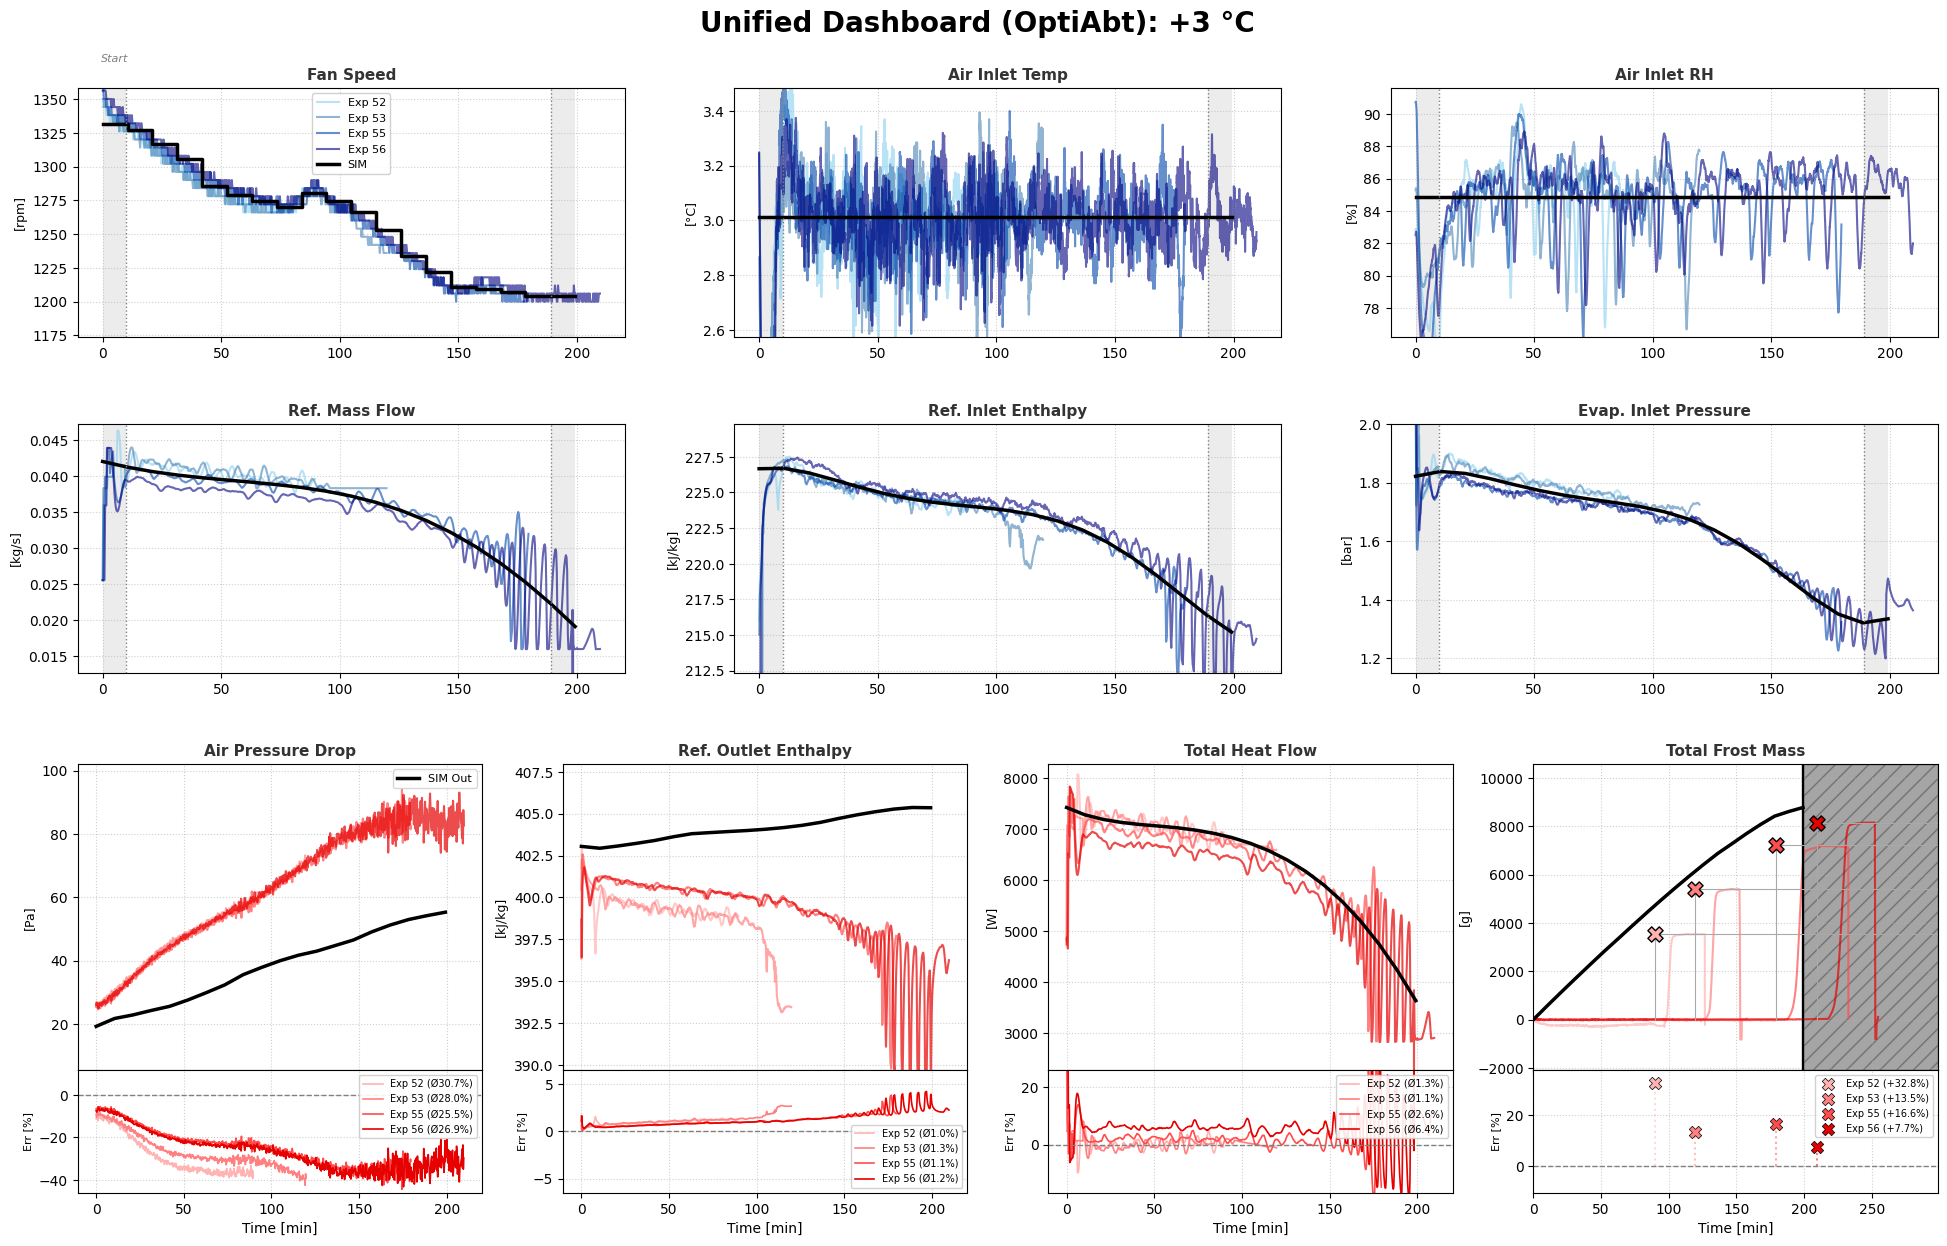

--- Visualizing 5 Experiments (OptiAbt) ---


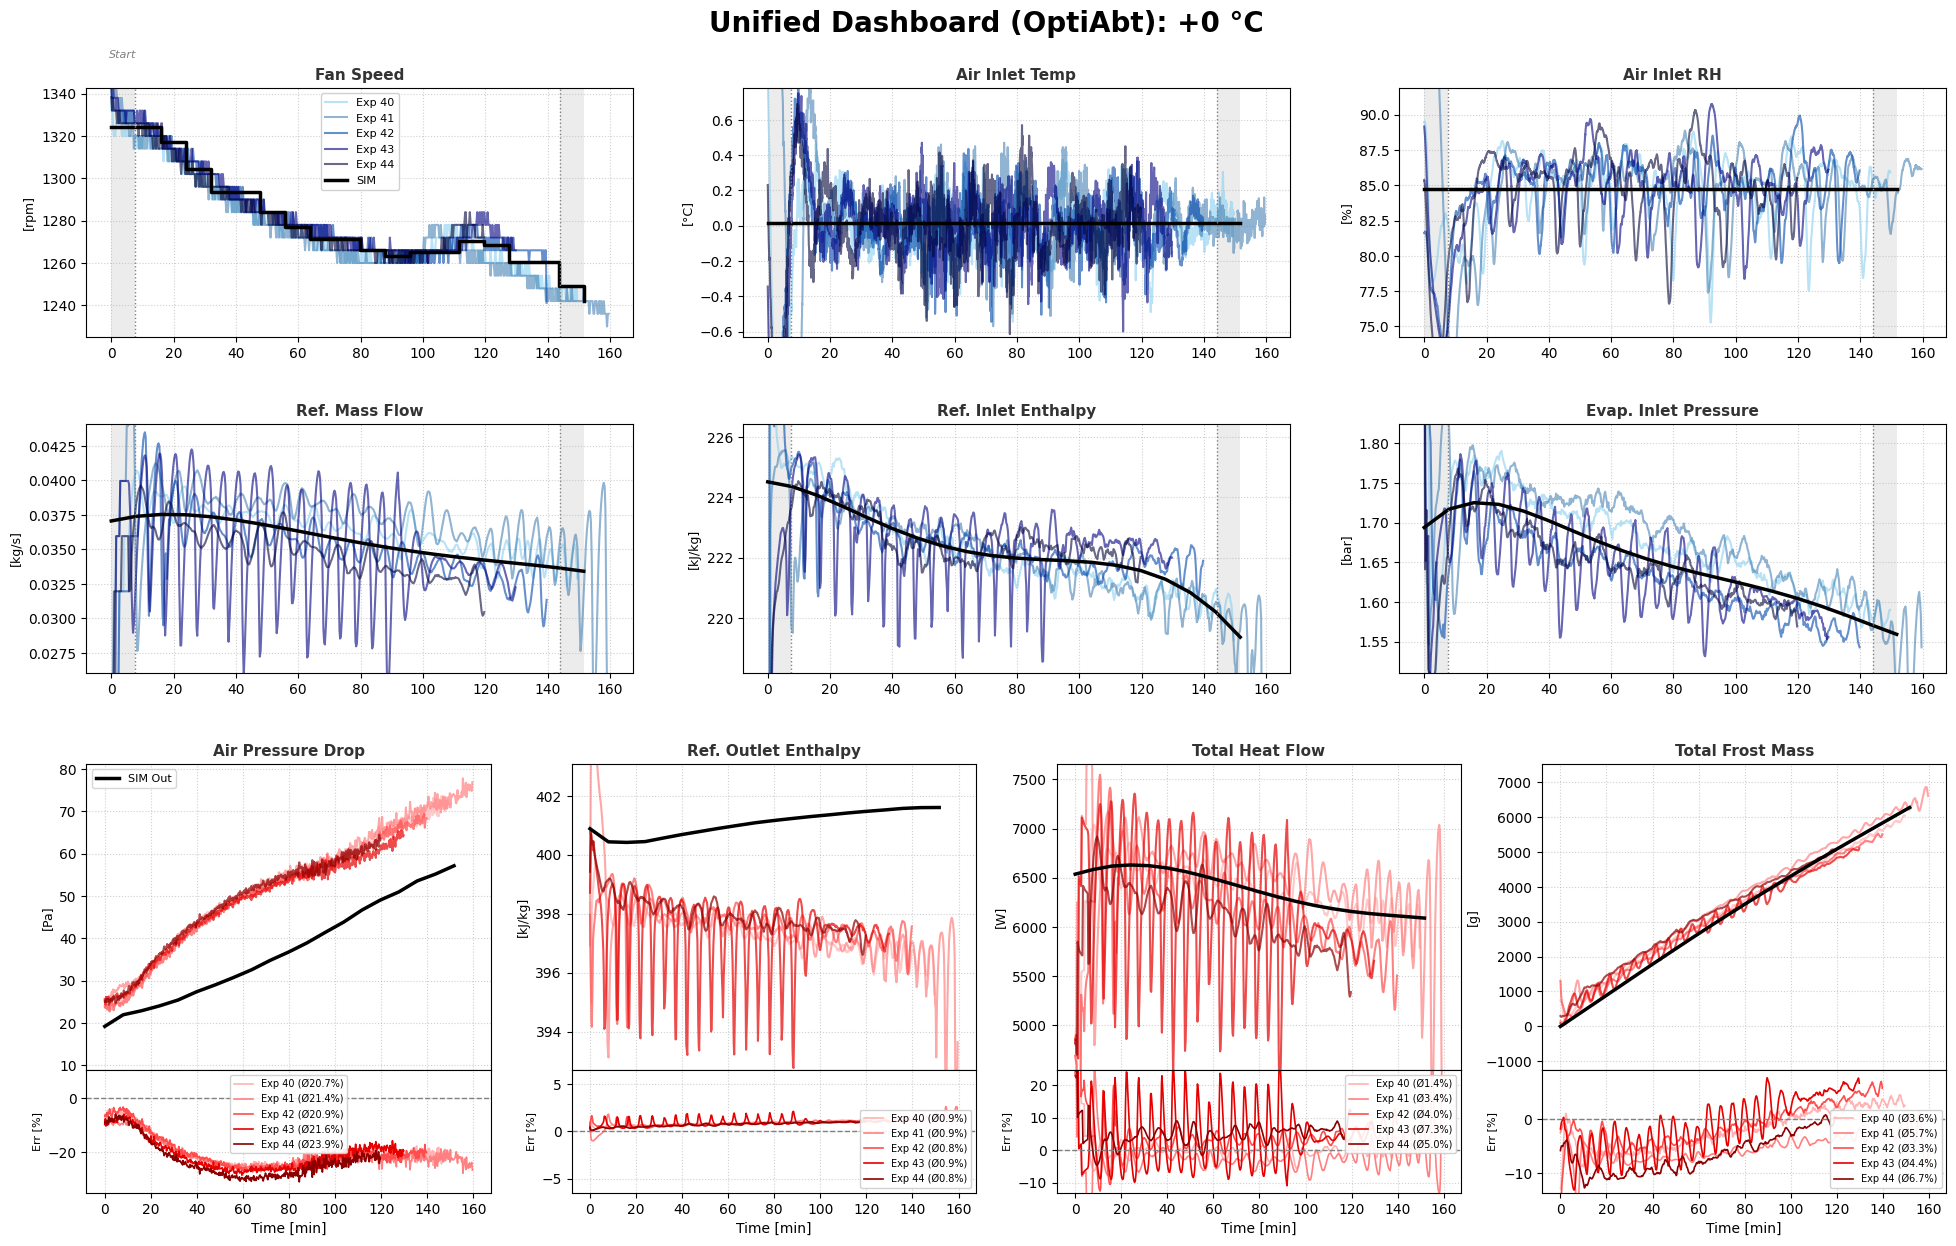

--- Visualizing 4 Experiments (OptiAbt) ---


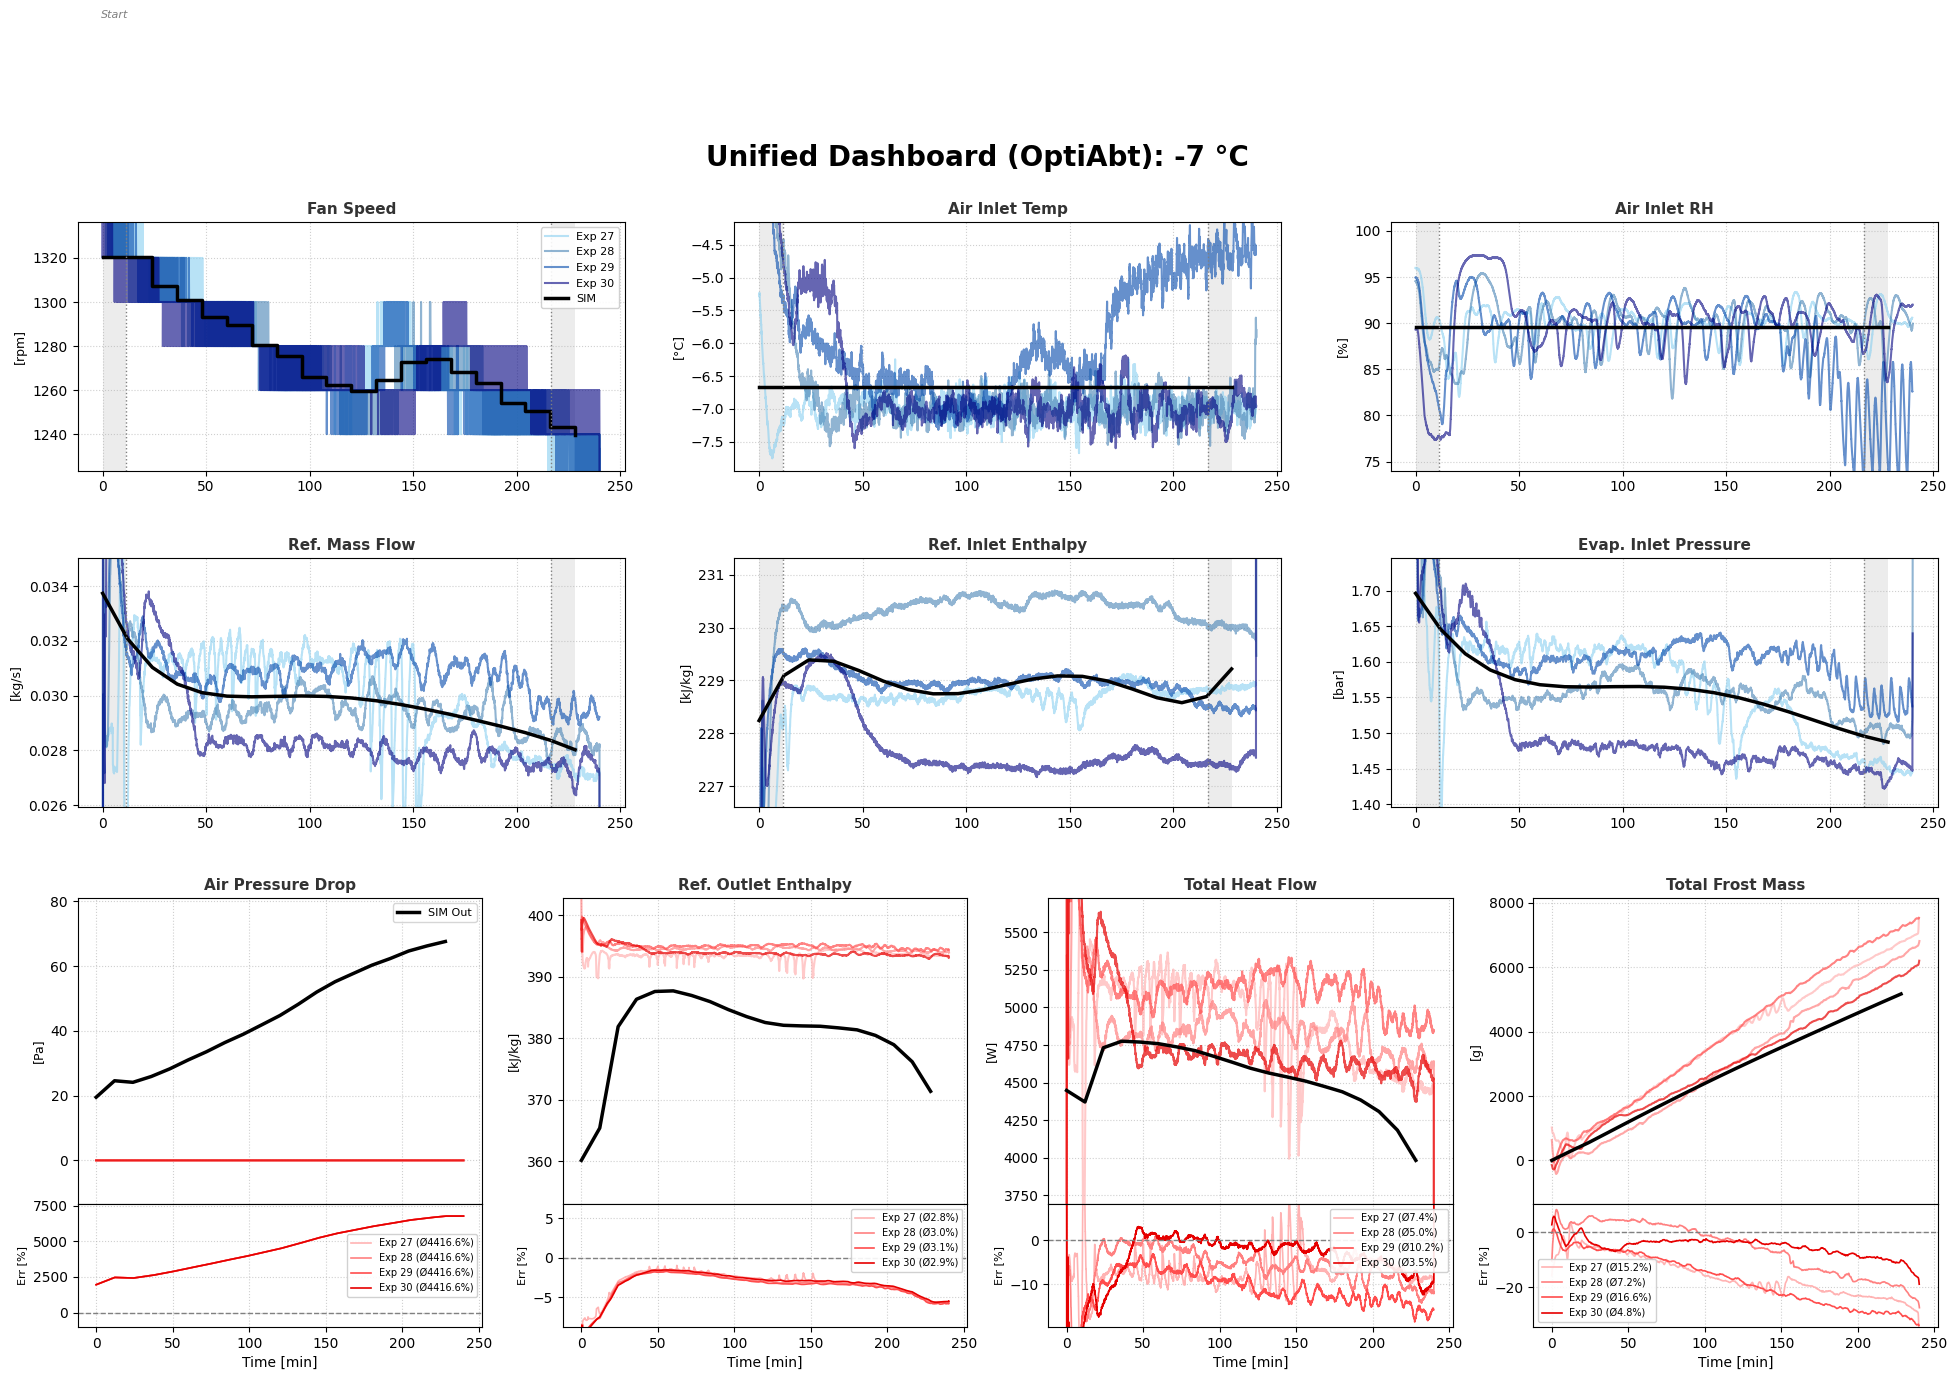

--- Visualizing 2 Experiments (OptiAbt) ---


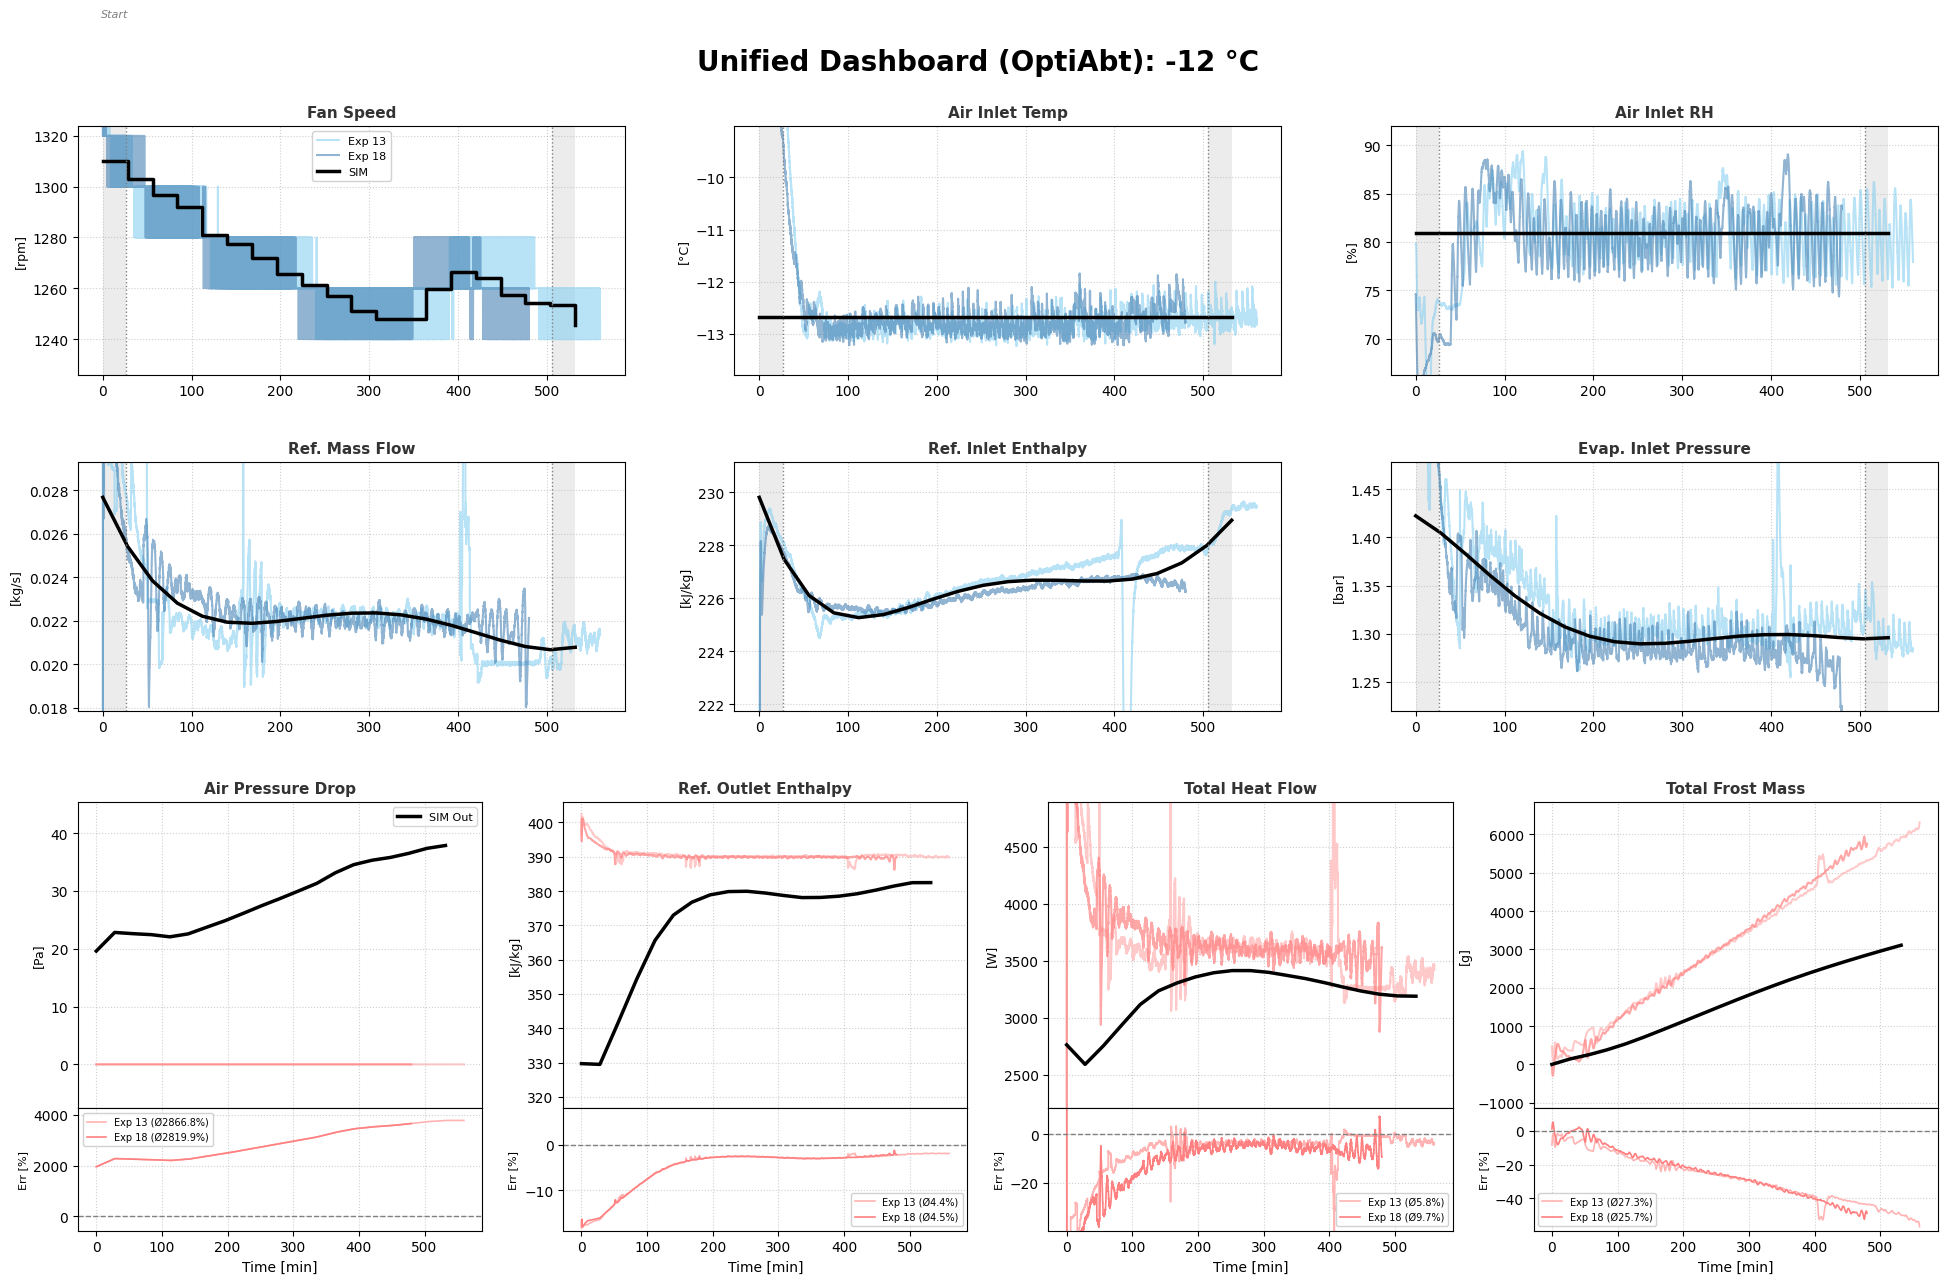

--- Visualizing 5 Experiments (OptiHorst) ---


d:\mbc_nba\vclibpy\frost_evaporator_nba\frost_evaporator\reporting.py:373: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax_main.axvspan(t_total, t_extended, color='#444444', alpha=0.15, hatch='//', edgecolor='gray')


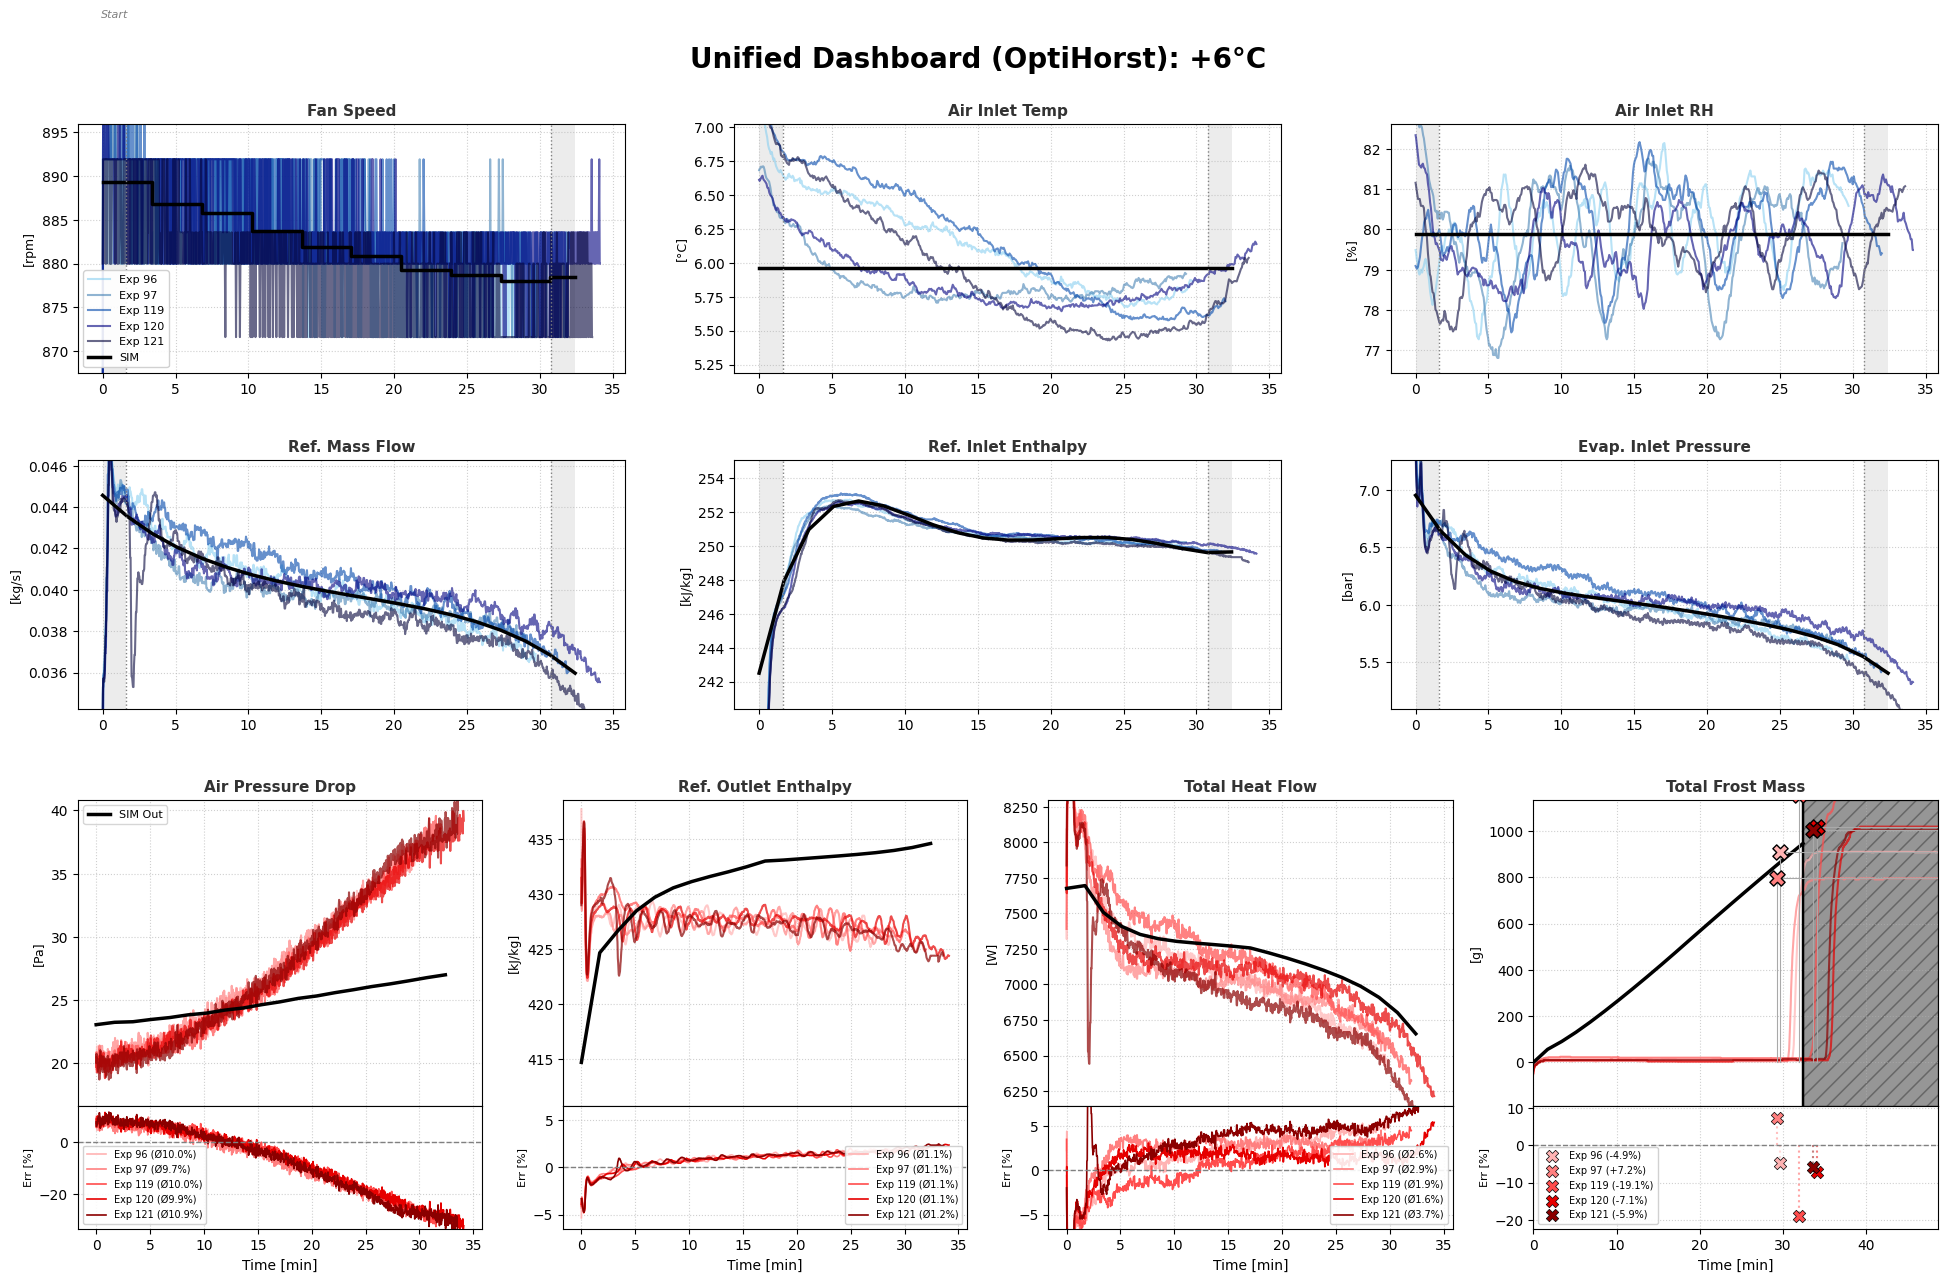

--- Visualizing 5 Experiments (OptiHorst) ---


d:\mbc_nba\vclibpy\frost_evaporator_nba\frost_evaporator\reporting.py:373: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax_main.axvspan(t_total, t_extended, color='#444444', alpha=0.15, hatch='//', edgecolor='gray')


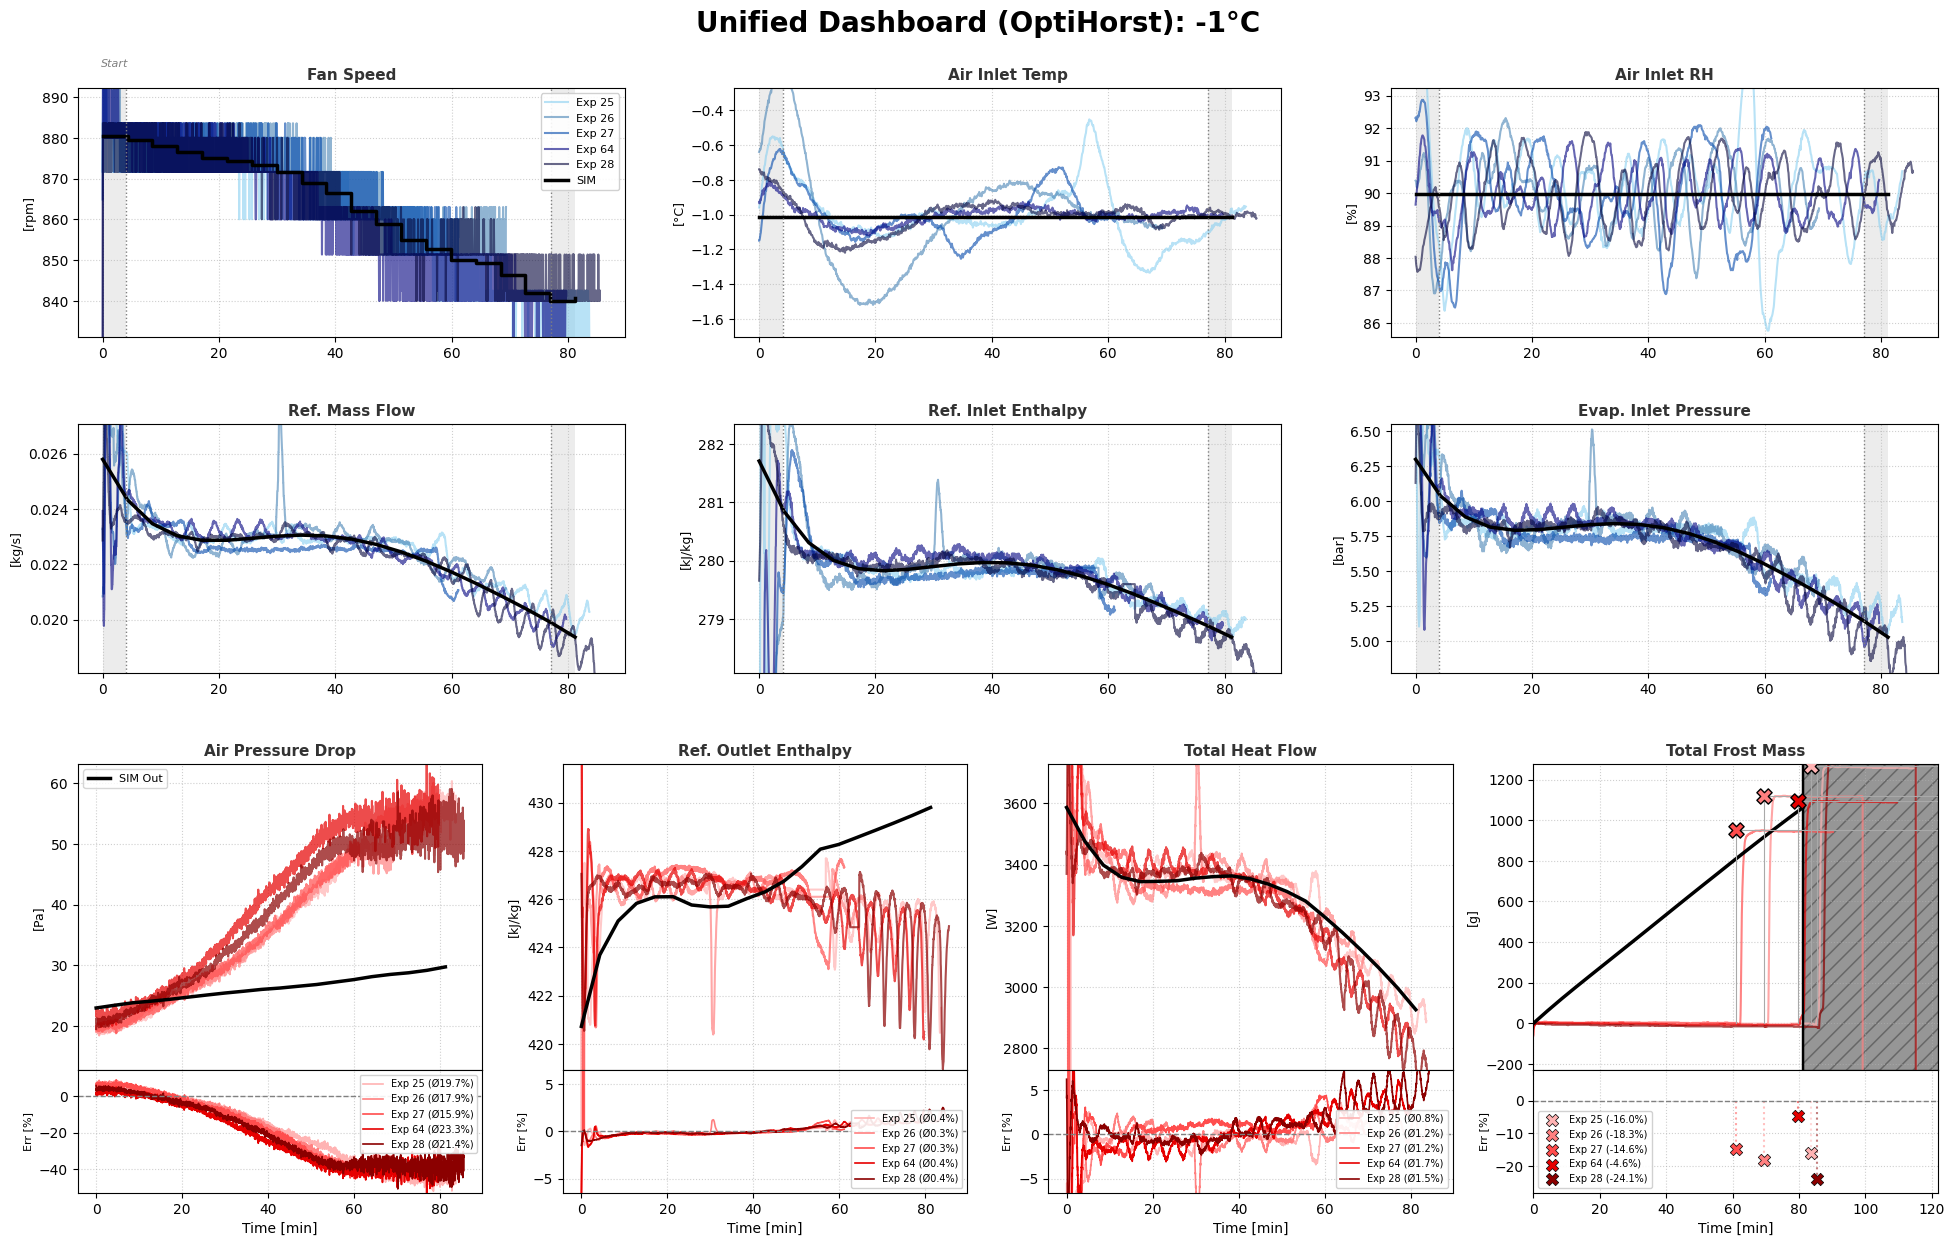

--- Visualizing 4 Experiments (OptiHorst) ---


d:\mbc_nba\vclibpy\frost_evaporator_nba\frost_evaporator\reporting.py:373: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax_main.axvspan(t_total, t_extended, color='#444444', alpha=0.15, hatch='//', edgecolor='gray')


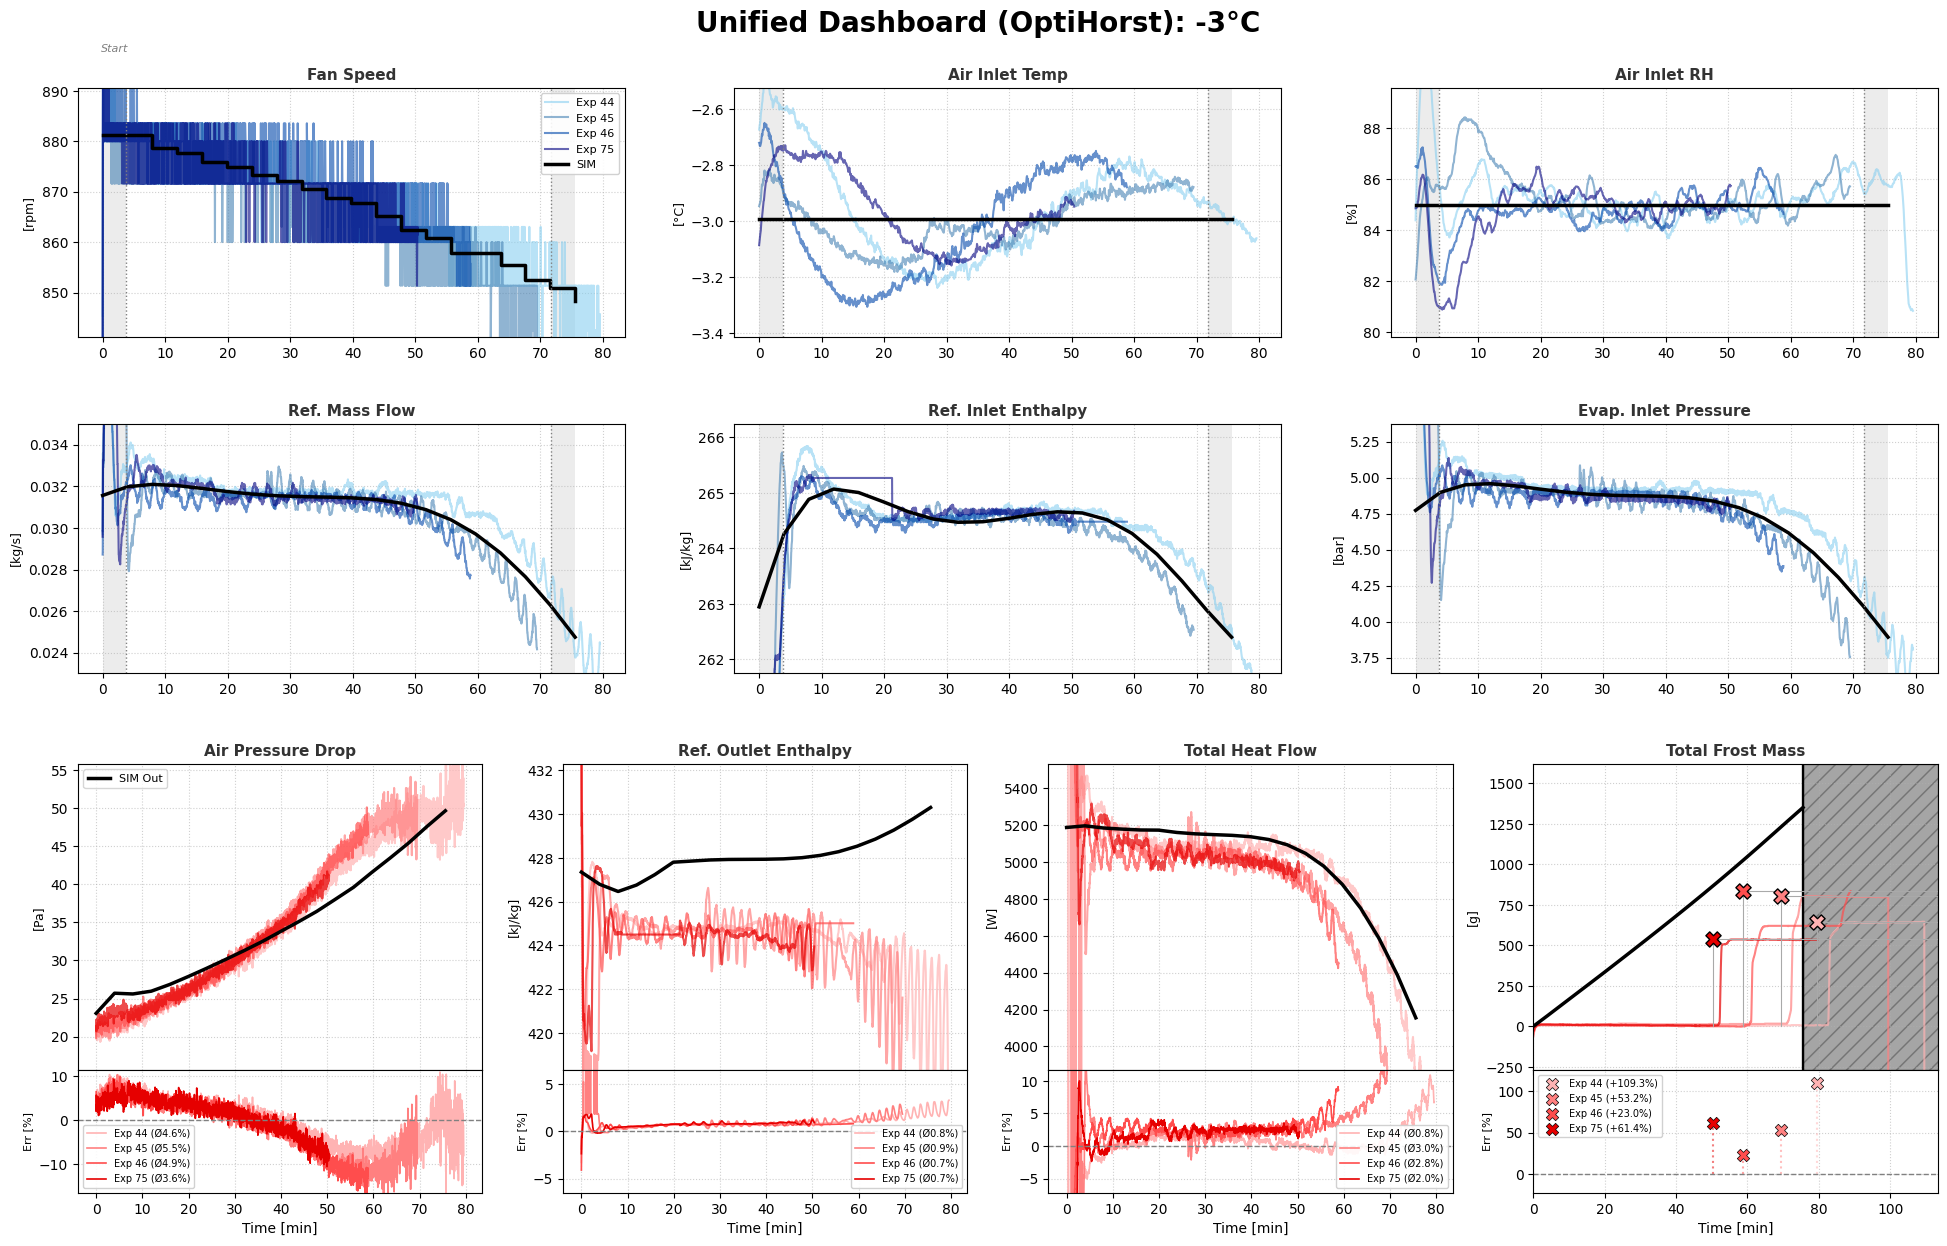

--- Visualizing 4 Experiments (OptiHorst) ---


d:\mbc_nba\vclibpy\frost_evaporator_nba\frost_evaporator\reporting.py:373: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax_main.axvspan(t_total, t_extended, color='#444444', alpha=0.15, hatch='//', edgecolor='gray')


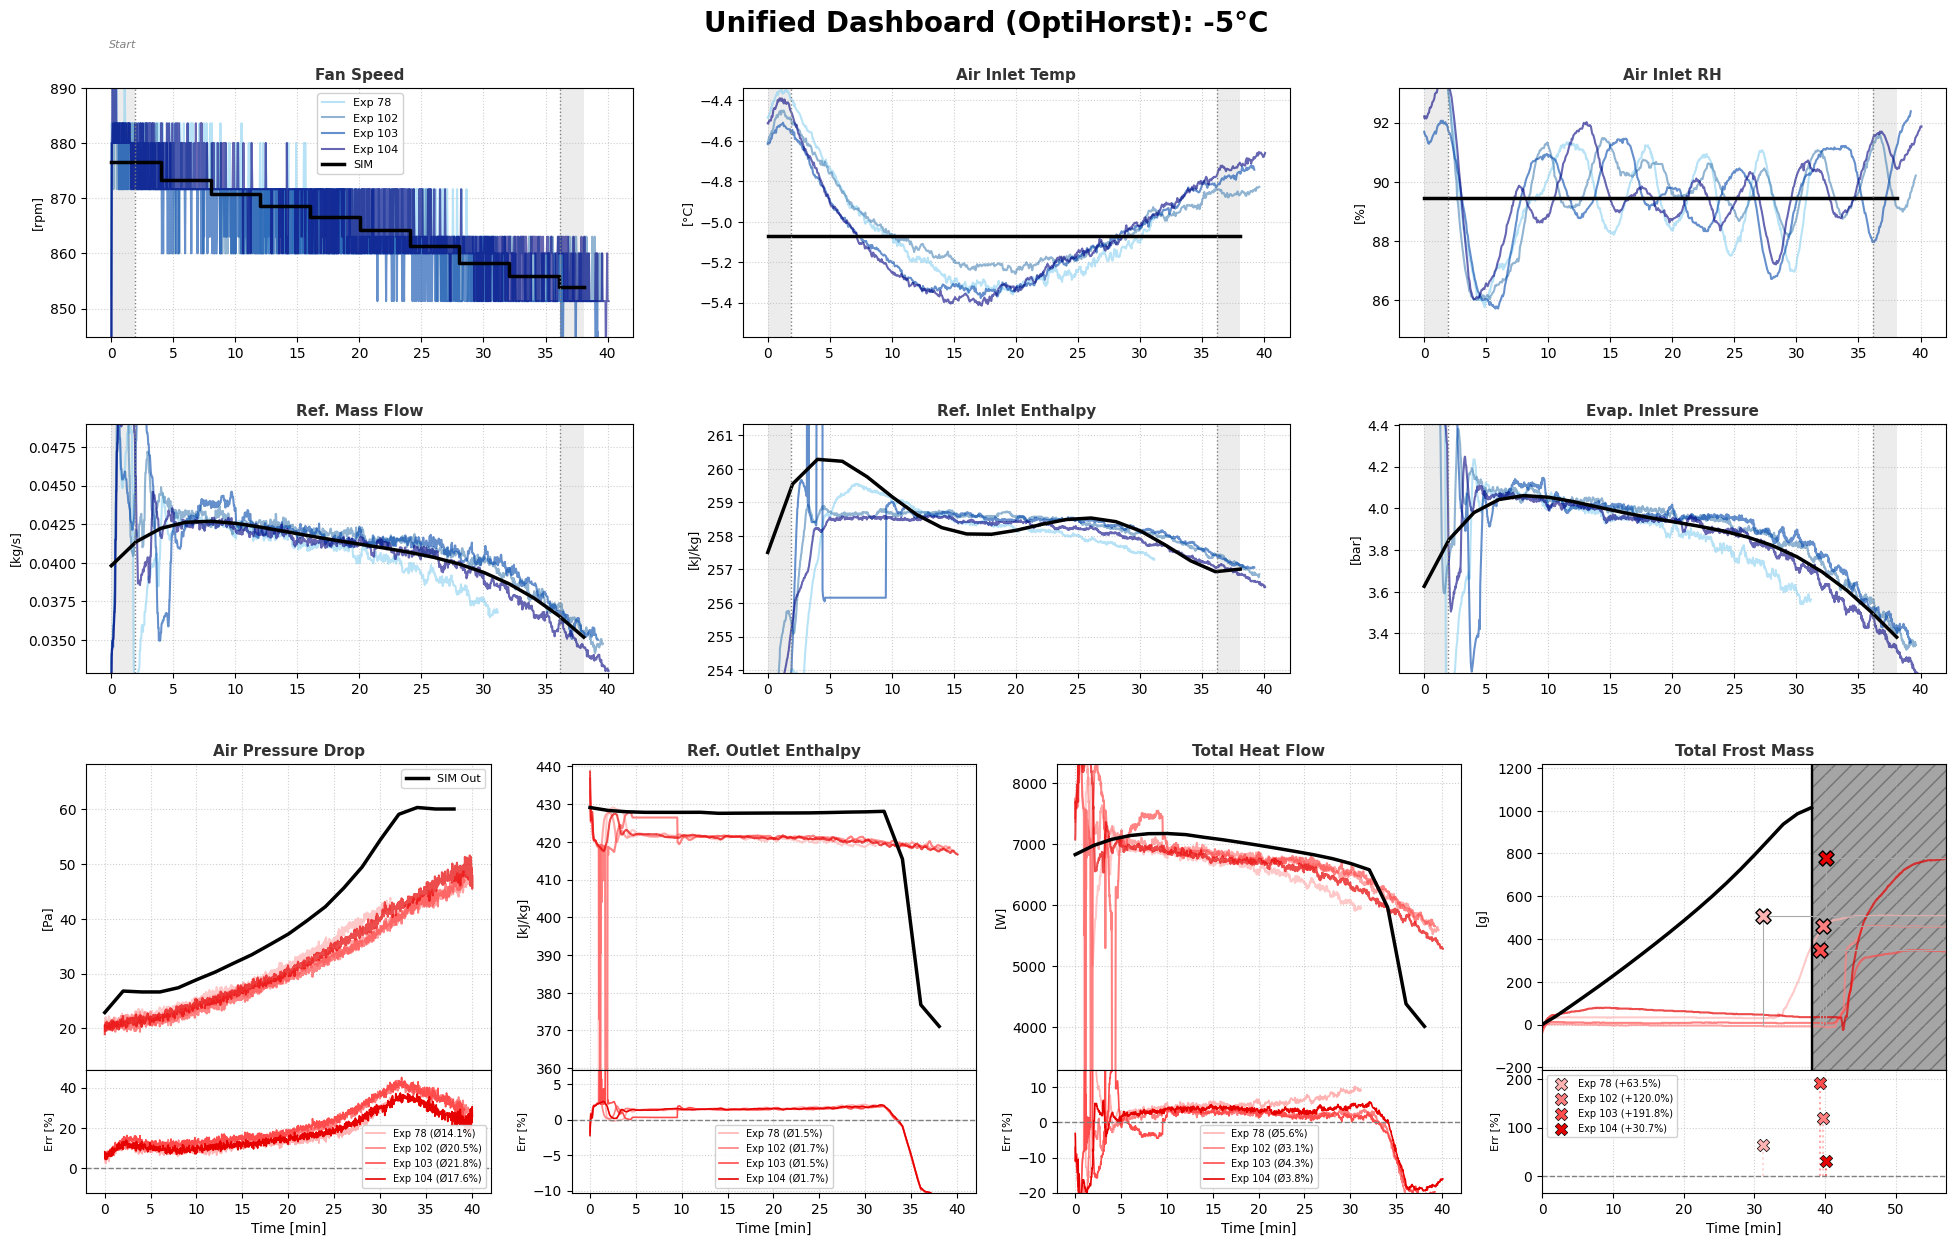

--- Visualizing 5 Experiments (OptiHorst) ---


d:\mbc_nba\vclibpy\frost_evaporator_nba\frost_evaporator\reporting.py:373: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax_main.axvspan(t_total, t_extended, color='#444444', alpha=0.15, hatch='//', edgecolor='gray')


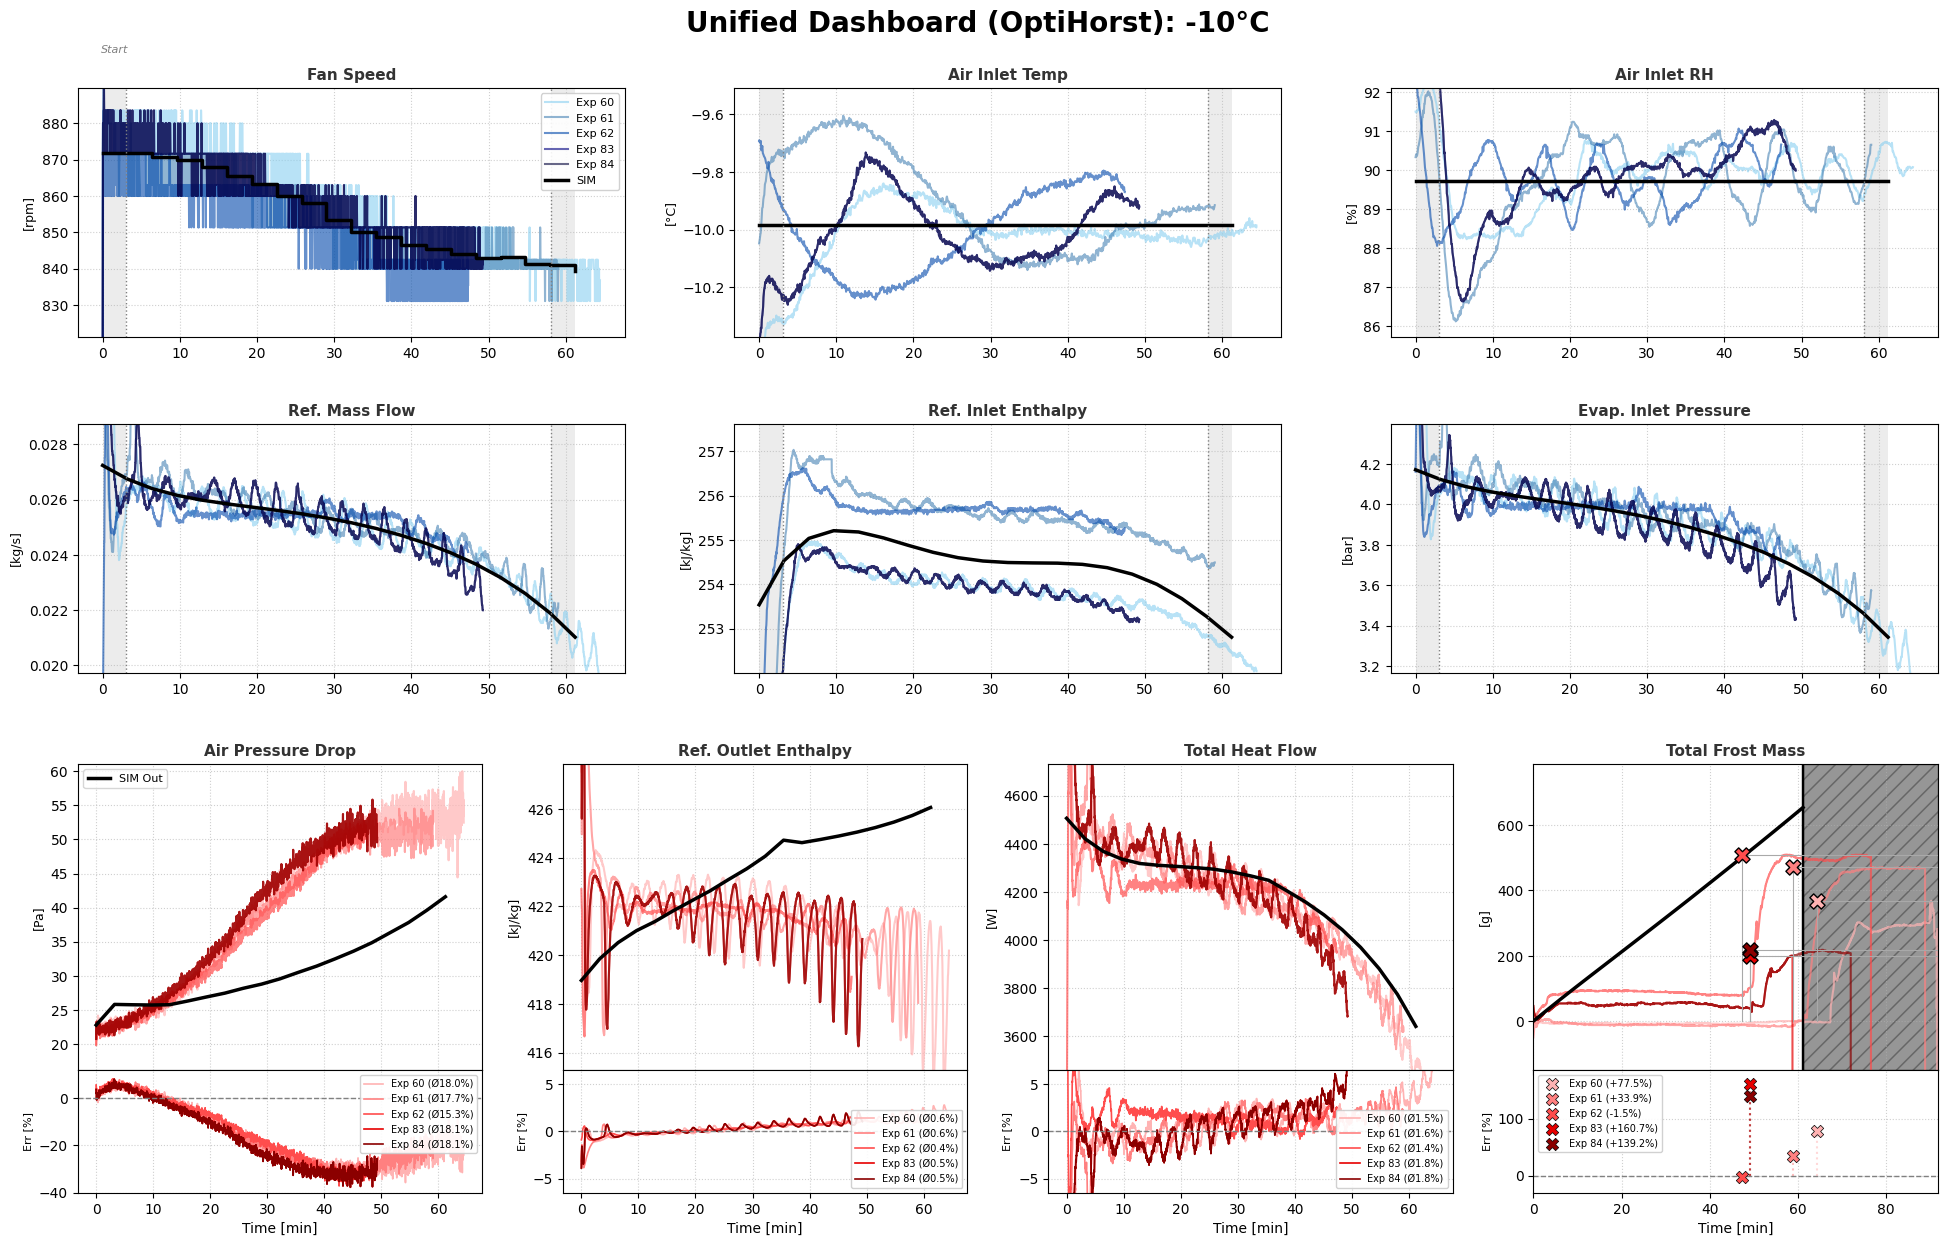

In [7]:
import pickle
import sys
import os
import pickle

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator import SimulationVisualizer


# --- Opti Abt ---


# Load the dictionary
with open("optiabt_histories.pkl", "rb") as f:
    abt_results = pickle.load(f)

group_names = list(abt_results.keys())

for group_name in group_names:

    use_melted = False

    if group_name == "+3 °C" or group_name == "Abt-a":
        use_melted = True

    # Get Data for the current group
    group_data   = abt_results[group_name]

    # Create a new visualizer instance
    viz_abt = SimulationVisualizer(group_data["params"])

    # Plot the comparison using the loaded data
    viz_abt.plot_comparison(states_history  = group_data["states_history"],
                            inputs_history  = group_data["inputs_history"], 
                            experiment_ids  = group_data["experiment_ids"], 
                            path_exp        = group_data["path_exp"], 
                            cutoff_pct      = group_data["cutoff_pct"], 
                            experiment_name = group_data["experiment_name"],
                            group_name      = group_name, 
                            save_fig        = False, 
                            use_melted_mass = use_melted,
    )




# --- OptiHorst ---

# Load the dictionary
with open("optihorst_histories.pkl", "rb") as f:
    horst_results = pickle.load(f)

group_names = list(horst_results.keys())

for group_name in group_names:

    # Get Data for the current group
    group_data   = horst_results[group_name]

    # Create a new visualizer instance
    viz_horst = SimulationVisualizer(group_data["params"])

    # Plot the comparison using the loaded data
    viz_horst.plot_comparison(states_history  = group_data["states_history"],
                              inputs_history  = group_data["inputs_history"], 
                              experiment_ids  = group_data["experiment_ids"], 
                              path_exp        = group_data["path_exp"], 
                              cutoff_pct      = group_data["cutoff_pct"], 
                              experiment_name = group_data["experiment_name"],
                              group_name      = group_name, 
                              save_fig        = False, 
    )